# LDA Failure on Nonlinear Dataset

## Objective
Identify a failure case of Linear Discriminant Analysis (LDA).

Tasks:
- Apply LDA
- Visualize projection
- Analyze why LDA fails


## Step 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns


## Step 2: Load Dataset

In [2]:
data = pd.read_csv('lda_failure_nonlinear.csv')

data.head()

,Feature1,Feature2,Label
0,-0.317227,0.096920,1
1,-0.116402,-0.467057,1
2,0.473903,0.875640,0
3,-0.344286,-0.111454,1
4,-0.212832,-1.063799,0


## Step 3: Understand Dataset

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Feature1  300 non-null    float64
 1   Feature2  300 non-null    float64
 2   Label     300 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 7.2 KB


In [4]:
data.iloc[:, -1].value_counts()

Label
1    150
0    150
Name: count, dtype: int64

## Step 4: Separate Features and Target

In [5]:
X = data.iloc[:, :-1]

y = data.iloc[:, -1]

print("Feature Shape :", X.shape)
print("Target Shape :", y.shape)

Feature Shape : (300, 2)
Target Shape : (300,)


## Step 5: Visualize Original Dataset

This helps understand the nonlinear structure before applying LDA.


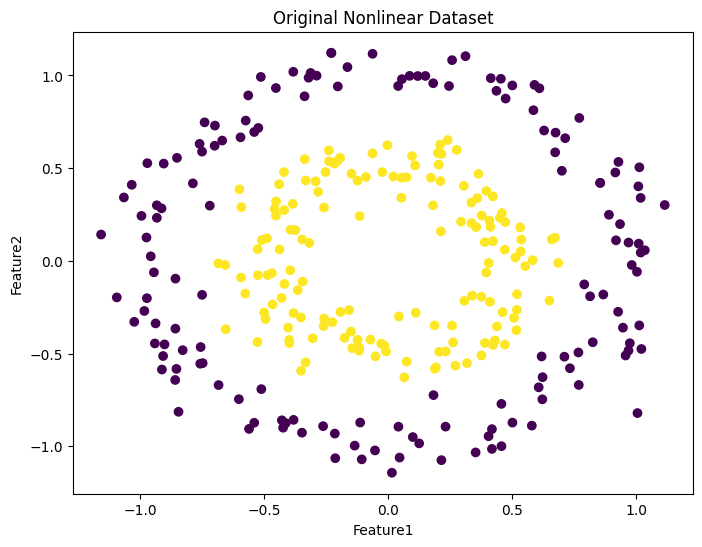

In [6]:
plt.figure(figsize=(8,6))

plt.scatter(
    X.iloc[:,0],
    X.iloc[:,1],
    c=y,
    cmap='viridis'
)

plt.xlabel(X.columns[0])
plt.ylabel(X.columns[1])

plt.title("Original Nonlinear Dataset")

plt.show()

## Step 6: Standardize Features

Standardization Formula:

z = (x - mean) / standard deviation


In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

## Step 7: Apply LDA

In [8]:
lda = LinearDiscriminantAnalysis(n_components=1)

X_lda = lda.fit_transform(X_scaled, y)

print(X_lda[:10])

[[-0.45408745]
 [-0.52452676]
 [ 1.37819099]
 [-0.64454734]
 [-1.10071871]
 [ 0.547509  ]
 [-0.51224944]
 [-0.77265822]
 [-0.9314578 ]
 [ 1.26346515]]


## Step 8: Visualize LDA Projection

LDA reduces the dataset into one dimension.


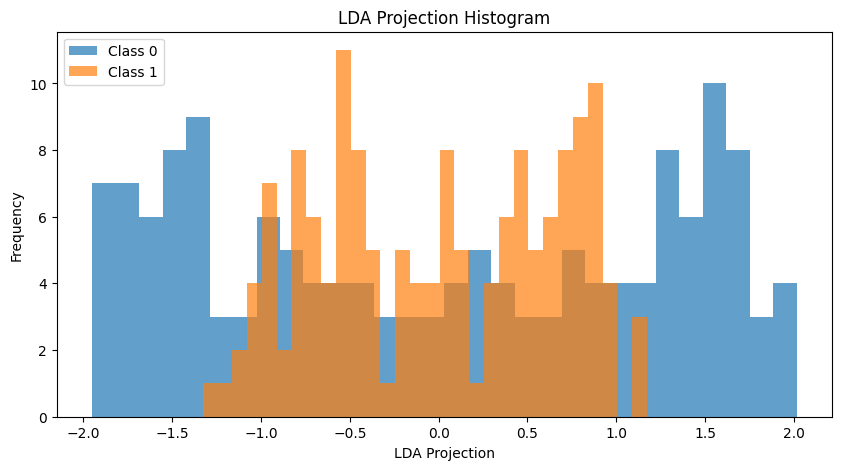

In [9]:
plt.figure(figsize=(10,5))

plt.hist(
    X_lda[y==0],
    bins=30,
    alpha=0.7,
    label='Class 0'
)

plt.hist(
    X_lda[y==1],
    bins=30,
    alpha=0.7,
    label='Class 1'
)

plt.xlabel("LDA Projection")

plt.ylabel("Frequency")

plt.title("LDA Projection Histogram")

plt.legend()

plt.show()

## Step 9: Understand the Projection Formula

LDA Projection Formula:

X_lda = XW

Where:
- X = original feature matrix
- W = projection vector


## Step 10: Why LDA Fails

LDA assumes:
- Classes are linearly separable
- Gaussian distributions
- Similar covariance matrices

Nonlinear datasets violate these assumptions.


## Step 11: Observe Class Overlap

If histograms overlap heavily:
- LDA cannot separate classes properly
- One linear boundary is insufficient


# Final Conclusions

## Q1. Does LDA separate the classes effectively?

No.

The classes usually overlap significantly after projection.

This indicates poor class separation.

## Q2. What is the shape of the data distribution?

The dataset follows a nonlinear shape.

Examples:
- Circular
- Spiral
- Curved clusters

These patterns cannot be separated using one straight line.

## Q3. Why does LDA fail in this case?

LDA creates only a linear boundary.

Nonlinear data requires curved decision regions.

Therefore:
- Means are not enough
- Linear projections lose important structure

## Q4. What type of boundary would be required instead?

A nonlinear boundary is required.

Examples:
- Circular boundary
- Polynomial boundary
- Kernel-based separation

Algorithms that work better:
- Kernel SVM
- Neural Networks
- Decision Trees
- Kernel PCA
